In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # choose `sp500_monthly (1).csv` in the dialog

# Get the actual uploaded filename (key of the dict)
filename = list(uploaded.keys())[0]
print("Loaded file:", filename)

df = pd.read_csv(filename)

# Basic checks
print(df.columns)
df.head()

Saving sp500_monthly (1).csv to sp500_monthly (1).csv
Loaded file: sp500_monthly (1).csv
Index(['Unnamed: 0', 'date', 'permno', 'comnam', 'ncusip', 'shrcd', 'exchcd',
       'hsiccd', 'ticker', 'gvkey', 'iid', 'start', 'ending', 'ret', 'prc',
       'shrout', 'vol', 'cfacpr', 'cfacshr'],
      dtype='object')


/tmp/ipykernel_10202/2570245787.py:10: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


,Unnamed: 0,date,permno,comnam,ncusip,shrcd,exchcd,hsiccd,ticker,gvkey,iid,start,ending,ret,prc,shrout,vol,cfacpr,cfacshr
0,1,2000-01-31,24010,ENTERGY CORP NEW,29364G10,11,1,4911,ETR,7366,1,1957-03-01,2024-12-31,-0.031553,24.9375,241283.0,190694.0,2.000000,2.0
1,3,2000-01-31,12749,K MART CORP,48258410,11,1,5331,KM,6307,1,1957-03-01,2002-01-16,-0.173913,8.3125,493698.0,874803.0,1.000000,1.0
2,5,2000-01-31,23819,HALLIBURTON CO,40621610,11,1,1389,HAL,5439,1,1957-03-01,2024-12-31,-0.102484,36.1250,441754.0,710393.0,2.000000,2.0
3,6,2000-01-31,25769,KERR MCGEE CORP,49238610,11,1,1311,KMG,6403,1,1984-10-04,2006-08-10,-0.108871,55.2500,86466.0,109249.0,2.176876,2.0
4,8,2000-01-31,13688,P G & E CORP,69331C10,11,1,4931,PCG,8264,1,1925-12-31,2019-01-17,0.070122,21.9375,383980.0,258969.0,1.000000,1.0


In [ ]:
import pandas as pd
import numpy as np

# Parse dates and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'permno']).copy()

# Standard CRSP-style filters
if 'shrcd' in df.columns:
    df = df[df['shrcd'].isin([10, 11])].copy()

if 'exchcd' in df.columns:
    df = df[df['exchcd'].isin([1, 2, 3])].copy()

# Clean returns
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df = df.dropna(subset=['ret']).copy()

print("Unique dates in filtered data:", df['date'].nunique())
print("Unique permnos in filtered data:", df['permno'].nunique())

# Build raw return panel
ret_panel_full = (
    df.pivot_table(index='date', columns='permno', values='ret', aggfunc='first')
      .sort_index()
)

print("Raw panel shape (T x N):", ret_panel_full.shape)

# -----------------------------
# Dynamic universe parameters
# -----------------------------
MIN_HISTORY = 60       # stock must have at least 60 past monthly returns
K_UNIVERSE = 350       # at each date, keep at most top 100 eligible stocks
MIN_PRICE = 0.1        # optional price screen, if prc exists

# Optional price panel for screening
if 'prc' in df.columns:
    df['prc'] = pd.to_numeric(df['prc'], errors='coerce')
    prc_panel_full = (
        df.pivot_table(index='date', columns='permno', values='prc', aggfunc='first')
          .sort_index()
          .abs()
    )
else:
    prc_panel_full = None

# Rolling count of available past returns, shifted so only information up to t is used
hist_count = ret_panel_full.notna().rolling(MIN_HISTORY).sum().shift(1)

# Build date-specific eligible universes
eligible_universe_by_date = {}

for date in ret_panel_full.index:
    eligible = hist_count.loc[date]
    eligible = eligible[eligible >= MIN_HISTORY].index.tolist()

    # Optional price filter using only info at date t
    if prc_panel_full is not None and date in prc_panel_full.index:
        eligible = [
            p for p in eligible
            if pd.notna(prc_panel_full.loc[date, p]) and prc_panel_full.loc[date, p] >= MIN_PRICE
        ]

    # Keep only up to K_UNIVERSE names
    eligible = eligible[:K_UNIVERSE]

    eligible_universe_by_date[date] = eligible

# Quick summary of universe sizes over time
universe_sizes = pd.Series({d: len(v) for d, v in eligible_universe_by_date.items()})
print("Universe size summary:")
print(universe_sizes.describe())

# Example: inspect first few dates with nonempty universes
print("\nFirst few nonempty universes:")
for d in universe_sizes[universe_sizes > 0].index[:5]:
    print(d.date(), "->", len(eligible_universe_by_date[d]), "stocks")

Unique dates in filtered data: 300
Unique permnos in filtered data: 971
Raw panel shape (T x N): (300, 971)
Universe size summary:
count    300.000000
mean     279.633333
std      140.056506
min        0.000000
25%      347.000000
50%      350.000000
75%      350.000000
max      350.000000
dtype: float64

First few nonempty universes:
2005-01-31 -> 350 stocks
2005-02-28 -> 350 stocks
2005-03-31 -> 350 stocks
2005-04-29 -> 350 stocks
2005-05-31 -> 350 stocks


In [ ]:
import numpy as np
import pandas as pd
import torch

# Set device for torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

portfolio_returns = []
benchmark_returns = []
weight_history = []

# Store previous weights by permno, since the universe changes over time
w_prev_dict = None

# Hyperparameters
ROLLING_WINDOW = 24   # months used to estimate mu and Sigma
GAMMA = 5.0           # risk aversion
KAPPA = 1.0           # turnover penalty strength
LR = 0.1              # learning rate
STEPS = 1000           # gradient steps per rebalance

dates = ret_panel_full.index.to_list()

print(f"#dates in full panel: {len(dates)}")
print("Universe size summary:")
print(universe_sizes.describe())


def estimate_moments(window_returns: pd.DataFrame):
    """
    window_returns: (T_window x N) DataFrame of past returns
    Returns:
        mu_t : (N,) mean vector
        Sigma_t : (N, N) covariance matrix
    """
    mu_t = window_returns.mean(axis=0).values
    Sigma_t = window_returns.cov().values

    # Ensure symmetry and add small jitter for stability
    Sigma_t = 0.5 * (Sigma_t + Sigma_t.T)
    eps = 1e-6
    Sigma_t = Sigma_t + eps * np.eye(Sigma_t.shape[0])

    return mu_t, Sigma_t


def get_prev_weights_for_current_universe(current_permnos, w_prev_dict):
    """
    Align previous weights to the current universe.
    Any stock not held previously gets weight 0.
    If no previous portfolio exists, start from equal weights.
    """
    current_N = len(current_permnos)

    if w_prev_dict is None:
        return np.ones(current_N) / current_N

    w_prev = np.array([w_prev_dict.get(p, 0.0) for p in current_permnos], dtype=float)

    # Renormalize if any mass remains; otherwise fall back to equal weights
    total = w_prev.sum()
    if total > 0:
        w_prev = w_prev / total
    else:
        w_prev = np.ones(current_N) / current_N

    return w_prev


def optimize_weights(mu_t, Sigma_t, w_prev=None):
    """
    Solve:
      max_w mu_t^T w - GAMMA * w^T Sigma_t w - KAPPA * ||w - w_prev||_1
      s.t. w lies on the simplex
    using logits + softmax in PyTorch.
    """
    mu_t_t = torch.tensor(mu_t, dtype=torch.float32, device=DEVICE)
    Sigma_t_t = torch.tensor(Sigma_t, dtype=torch.float32, device=DEVICE)

    current_N = mu_t.shape[0]

    if w_prev is None:
        w_prev_np = np.ones(current_N) / current_N
    else:
        w_prev_np = np.asarray(w_prev, dtype=float)

    w_prev_t = torch.tensor(w_prev_np, dtype=torch.float32, device=DEVICE)

    # Initialize logits near previous weights
    v = torch.log(w_prev_t + 1e-8)
    v = v.detach().clone().requires_grad_(True)

    optimizer = torch.optim.SGD([v], lr=LR)

    for _ in range(STEPS):
        optimizer.zero_grad()

        w = torch.softmax(v, dim=0)
        exp_ret = torch.dot(mu_t_t, w)
        var = w @ Sigma_t_t @ w
        turnover = torch.abs(w - w_prev_t).sum()

        objective = exp_ret - GAMMA * var - KAPPA * turnover
        loss = -objective
        loss.backward()
        optimizer.step()

    w_opt = torch.softmax(v, dim=0).detach().cpu().numpy()
    return w_opt

#dates in full panel: 300
Universe size summary:
count    300.000000
mean     279.633333
std      140.056506
min        0.000000
25%      347.000000
50%      350.000000
75%      350.000000
max      350.000000
dtype: float64


In [ ]:
import numpy as np
import pandas as pd
import torch

# Set device for torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

portfolio_returns = []
benchmark_returns = []
weight_history = []

# Previous portfolio stored by permno
w_prev_dict = None

# Rebalance through time
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t, based only on info available at t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if the eligible universe is too small
    if len(current_permnos) < 2:
        continue

    # Use the previous ROLLING_WINDOW months for estimation
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Require a fully observed estimation window for the current universe
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    # Need at least 2 assets left after missing-data filtering
    if len(current_permnos) < 2:
        continue

    # Get next-month realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]

    # IMPORTANT:
    # do NOT use date_{t+1} availability to change the portfolio at date t
    # Temporary safe rule: treat missing next-month returns as 0
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments from the rolling window
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to the current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize at time t
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno for turnover alignment next period
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history.append((date_t, current_permnos, w_t))

    port_ret = float(np.dot(w_t, r_next_eval.values))

    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    portfolio_returns.append(port_ret)
    benchmark_returns.append(bench_ret)

print(len(portfolio_returns), len(benchmark_returns))

239 239


Optimized portfolio:
  mean_ret_monthly: 0.0096
  vol_annual: 0.1647
  sharpe_annual: 0.6963
  max_drawdown: -0.5292
  cum_return: 6.4129

Equal-weight benchmark:
  mean_ret_monthly: 0.0097
  vol_annual: 0.1691
  sharpe_annual: 0.6867
  max_drawdown: -0.5344
  cum_return: 6.5265


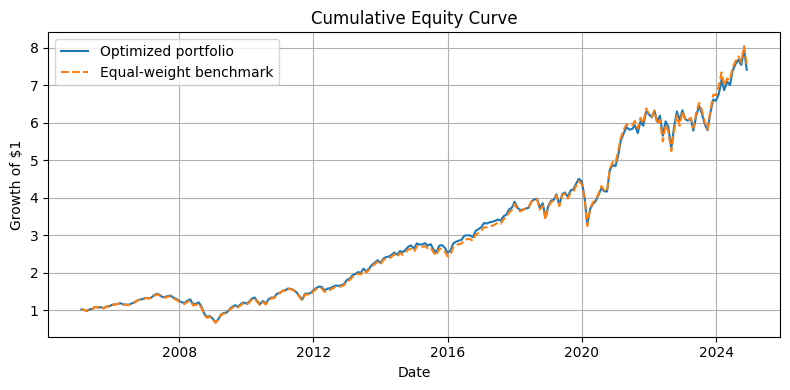

ROLLING_WINDOW = 24
GAMMA = 5.0
KAPPA = 1.0
LR = 0.1
STEPS = 1000
DEVICE = cpu
ret_panel_full shape = (300, 971)
universe hash sample = 300 [(Timestamp('2000-01-31 00:00:00'), []), (Timestamp('2000-02-29 00:00:00'), [])]
estimate_moments id = 136152711459552
optimize_weights id = 136152107546272


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def performance_metrics(returns, freq=12):
    returns = np.asarray(returns, dtype=float)

    if len(returns) == 0:
        return {
            "mean_ret_monthly": np.nan,
            "vol_annual": np.nan,
            "sharpe_annual": np.nan,
            "max_drawdown": np.nan,
            "cum_return": np.nan,
            "equity_curve": np.array([]),
        }

    mean_ret = returns.mean()
    std_ret = returns.std(ddof=1) if len(returns) > 1 else np.nan

    if std_ret is not np.nan and std_ret > 0:
        sharpe = np.sqrt(freq) * mean_ret / std_ret
    else:
        sharpe = np.nan

    vol_annual = std_ret * np.sqrt(freq) if not np.isnan(std_ret) else np.nan

    equity = (1 + returns).cumprod()
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1.0
    max_dd = drawdown.min()

    total_cum_ret = equity[-1] - 1.0

    return {
        "mean_ret_monthly": mean_ret,
        "vol_annual": vol_annual,
        "sharpe_annual": sharpe,
        "max_drawdown": max_dd,
        "cum_return": total_cum_ret,
        "equity_curve": equity,
    }

port_ret_arr = np.array(portfolio_returns, dtype=float)
bench_ret_arr = np.array(benchmark_returns, dtype=float)

metrics_port = performance_metrics(port_ret_arr, freq=12)
metrics_bench = performance_metrics(bench_ret_arr, freq=12)

print("Optimized portfolio:")
for k, v in metrics_port.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\nEqual-weight benchmark:")
for k, v in metrics_bench.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual rebalance dates if available
backtest_dates = [x[0] for x in weight_history]

plt.figure(figsize=(8, 4))
plt.plot(backtest_dates, metrics_port["equity_curve"], label="Optimized portfolio")
plt.plot(backtest_dates, metrics_bench["equity_curve"], label="Equal-weight benchmark", linestyle="--")
plt.title("Cumulative Equity Curve")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

In [ ]:
dates_bt = [d for d, _, _ in weight_history]

# Collect all permnos that ever appear
all_permnos = sorted({p for _, plist, _ in weight_history for p in plist})

# Build a time-by-asset weight matrix, filling missing entries with 0
W_df = pd.DataFrame(0.0, index=dates_bt, columns=all_permnos)

for d, plist, w in weight_history:
    W_df.loc[d, plist] = w

print("Weight matrix shape:", W_df.shape)

avg_weights = W_df.mean(axis=0)

weight_summary = (
    pd.DataFrame({
        "permno": avg_weights.index,
        "avg_weight": avg_weights.values
    })
    .sort_values("avg_weight", ascending=False)
)

weight_summary.head(10)

Weight matrix shape: (239, 684)


,permno,avg_weight
244,39642,0.004563
145,22592,0.004562
427,75510,0.004561
125,19561,0.004559
278,46578,0.004557
261,42906,0.004557
264,43449,0.004557
154,23229,0.004555
20,11404,0.004555
379,64390,0.004554


In [ ]:
import numpy as np
import pandas as pd

dates_bt = [d for d, _, _ in weight_history]

# Collect all permnos that ever appear
all_permnos = sorted({p for _, plist, _ in weight_history for p in plist})

# Build a full time-by-asset weight matrix, filling missing weights with 0
W_df = pd.DataFrame(0.0, index=dates_bt, columns=all_permnos)

for d, plist, w in weight_history:
    W_df.loc[d, plist] = w

W = W_df.values

print("Weight matrix shape:", W.shape)

# Equal-weight benchmark over the union of all assets
ew_full = np.ones(W.shape[1]) / W.shape[1]

# Average L1 distance from this full-sample equal-weight vector
avg_l1_dist = np.mean(np.abs(W - ew_full).sum(axis=1))
print("Average L1 distance from equal-weight:", avg_l1_dist)

# Average turnover
turnover_series = np.abs(np.diff(W, axis=0)).sum(axis=1)
print("Average turnover per rebalance:", turnover_series.mean())

Weight matrix shape: (239, 684)
Average L1 distance from equal-weight: 1.3277939860227874
Average turnover per rebalance: 0.006272274346998564


Sanity Check: Are We Really Avoiding the Equal-Weight Regime?

Before interpreting the full backtest, we verify that the optimizer responds to differences in asset quality rather than mechanically producing something close to an equal-weight portfolio. If some assets have higher estimated returns than others, the optimizer should assign them larger weights, all else equal. If it instead always returns nearly equal weights, that would suggest either an implementation error, a failure of the gradient-based optimization routine, or parameter choices that overwhelm the return signal.

To check this, we run a simple two-asset experiment using the same optimization code as in the main model. We first compute the average monthly return of each stock in the return panel and select one “good” stock with a relatively high average return and one “bad” stock with a relatively low average return. We then restrict the data to these two assets and estimate the mean vector and covariance matrix over the same rolling window used in the main backtest. Using these estimated moments, we solve the same constrained portfolio optimization problem as in the main model, imposing no short selling and full investment. For this diagnostic exercise, we temporarily set the turnover penalty to zero and do not supply previous weights, so that the optimizer selects the portfolio from scratch.

If the implementation is working correctly, the optimizer should assign more than half the weight to the better-performing stock and less than half to the worse-performing stock. This would show that the model is capable of tilting toward higher-return assets rather than defaulting to equal weights. As an additional check, we repeat the exercise on simple synthetic data in which one asset has a higher mean return while both assets share the same covariance structure. The optimizer again places greater weight on the higher-return asset.

Together, these exercises confirm that the objective and constraints are implemented correctly, that the PyTorch optimization routine is functioning as intended, and that the model is not mechanically stuck in an equal-weight regime.

In [ ]:
# === More robust sanity check: choose good and bad stocks with enough overlap ===

import numpy as np
import pandas as pd

MIN_OVERLAP = ROLLING_WINDOW

# Keep only stocks with at least MIN_OVERLAP observed returns
valid_counts = ret_panel_full.notna().sum(axis=0)
eligible_cols = valid_counts[valid_counts >= MIN_OVERLAP].index

ret_candidates = ret_panel_full[eligible_cols]

# Mean return among eligible stocks
mean_ret = ret_candidates.mean(axis=0, skipna=True).dropna()

# Sort from best to worst
sorted_permnos = mean_ret.sort_values(ascending=False)

good_permno = None
bad_permno = None
ret_two = None

# Try to find a high-mean and low-mean pair with enough overlapping observations
for g in sorted_permnos.index:
    for b in sorted_permnos.index[::-1]:
        if g == b:
            continue
        temp = ret_panel_full[[g, b]].dropna()
        if len(temp) >= MIN_OVERLAP:
            good_permno = g
            bad_permno = b
            ret_two = temp.copy()
            break
    if ret_two is not None:
        break

if ret_two is None:
    raise ValueError("Could not find a good/bad stock pair with enough overlapping observations.")

print("Good stock:", good_permno, "| Mean monthly return:", float(mean_ret[good_permno]))
print("Bad stock :", bad_permno,  "| Mean monthly return:", float(mean_ret[bad_permno]))
print("Overlap length:", len(ret_two))
display(ret_two.head())

Good stock: 22623 | Mean monthly return: 0.05423232352941176
Bad stock : 15850 | Mean monthly return: -0.027062725
Overlap length: 34


permno,22623,15850
date,,
2022-03-31,0.223358,-0.024666
2022-04-29,0.052622,-0.272117
2022-05-31,0.050853,-0.004675
2022-06-30,-0.077642,-0.115385
2022-07-29,0.154384,0.051944


In [ ]:
# === Sanity check: run optimizer on the chosen good/bad pair ===

import numpy as np

# Use the last ROLLING_WINDOW overlapping months
window_returns_two = ret_two.iloc[-ROLLING_WINDOW:]

# Estimate moments
mu_t_two, Sigma_t_two = estimate_moments(window_returns_two)

print("Estimated mu_t for [good, bad]:", mu_t_two)
print("Sigma_t_two:\n", Sigma_t_two)

# Temporarily remove turnover penalty
KAPPA_old = KAPPA
KAPPA = 0.0

# Fresh optimization
w_opt_two = optimize_weights(mu_t_two, Sigma_t_two, w_prev=None)

# Restore original KAPPA
KAPPA = KAPPA_old

print("\nGood stock permno:", good_permno)
print("Bad stock permno :", bad_permno)
print("Optimal weights [good, bad]:", w_opt_two)
print("Equal weight would be       :", np.array([0.5, 0.5]))
print("Sum of weights              :", w_opt_two.sum())

Estimated mu_t for [good, bad]: [ 0.04719583 -0.00219671]
Sigma_t_two:
 [[ 0.01373784 -0.00022294]
 [-0.00022294  0.01666936]]

Good stock permno: 22623
Bad stock permno : 15850
Optimal weights [good, bad]: [0.698585 0.301415]
Equal weight would be       : [0.5 0.5]
Sum of weights              : 1.0


In [ ]:
# === Sanity check with lower GAMMA and no turnover penalty ===

import numpy as np

# Save original globals
GAMMA_orig = GAMMA
KAPPA_orig = KAPPA

# Relax penalties
GAMMA = 1.0
KAPPA = 0.0

print(f"Running with GAMMA={GAMMA}, KAPPA={KAPPA}")
print(f"Good stock permno: {good_permno}")
print(f"Bad stock permno : {bad_permno}")
print(f"Estimated mean returns [good, bad]: {mu_t_two}")

# Run optimizer
w_opt_low_gamma = optimize_weights(mu_t_two, Sigma_t_two, w_prev=None)

print("\nOptimal weights [good, bad]:", w_opt_low_gamma)
print("Equal weight would be       :", np.array([0.5, 0.5]))
print("Sum of weights              :", w_opt_low_gamma.sum())

# Restore globals
GAMMA = GAMMA_orig
KAPPA = KAPPA_orig
print(f"\nRestored globals: GAMMA={GAMMA}, KAPPA={KAPPA}")

Running with GAMMA=1.0, KAPPA=0.0
Good stock permno: 22623
Bad stock permno : 15850
Estimated mean returns [good, bad]: [ 0.04719583 -0.00219671]

Optimal weights [good, bad]: [0.83039296 0.16960706]
Equal weight would be       : [0.5 0.5]
Sum of weights              : 1.0

Restored globals: GAMMA=5.0, KAPPA=1.0


In [ ]:
# === Sanity check: check convergence by increasing LR and STEPS ===

import numpy as np

# Save globals
GAMMA_orig = GAMMA
KAPPA_orig = KAPPA
LR_orig = LR
STEPS_orig = STEPS

# Relax penalties
GAMMA = 1.0
KAPPA = 0.0

# More aggressive optimization settings
LR = 2.0
STEPS = 2000

print(f"Running with GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")
print(f"Good stock permno: {good_permno}")
print(f"Bad stock permno : {bad_permno}")
print(f"Estimated mean returns [good, bad]: {mu_t_two}")

# Equal-weight reference
w_eq = np.array([0.5, 0.5])

def objective_value(w, mu, Sigma, gamma, kappa, w_prev=None):
    if w_prev is None:
        w_prev = np.zeros_like(w)
    exp_ret = np.dot(mu, w)
    var = float(w @ Sigma @ w)
    turnover = np.abs(w - w_prev).sum()
    return exp_ret - gamma * var - kappa * turnover

obj_eq = objective_value(w_eq, mu_t_two, Sigma_t_two, GAMMA, KAPPA, w_prev=np.zeros(2))

# Run optimizer
w_opt_fast = optimize_weights(mu_t_two, Sigma_t_two, w_prev=None)
obj_opt = objective_value(w_opt_fast, mu_t_two, Sigma_t_two, GAMMA, KAPPA, w_prev=np.zeros(2))

print("\nOptimal weights [good, bad]:", w_opt_fast)
print("Equal weight would be       :", w_eq)
print("Sum of weights              :", w_opt_fast.sum())
print("Objective at equal weight   :", obj_eq)
print("Objective at optimum        :", obj_opt)

# Restore globals
GAMMA = GAMMA_orig
KAPPA = KAPPA_orig
LR = LR_orig
STEPS = STEPS_orig
print("\nRestored globals.")

Running with GAMMA=1.0, KAPPA=0.0, LR=2.0, STEPS=2000
Good stock permno: 22623
Bad stock permno : 15850
Estimated mean returns [good, bad]: [ 0.04719583 -0.00219671]

Optimal weights [good, bad]: [0.99431026 0.00568978]
Equal weight would be       : [0.5 0.5]
Sum of weights              : 1.0
Objective at equal weight   : 0.015009229150319294
Objective at optimum        : 0.033334826883353076

Restored globals.


In [ ]:
# === RE-RUN FULL BACKTEST WITH AGGRESSIVE SETTINGS ===

import numpy as np
import pandas as pd
import torch

# 1. Update hyperparameters based on sanity check
GAMMA = 1.0
KAPPA = 0.005
LR = 0.1
STEPS = 1000

print(f"Re-running backtest with: GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")

portfolio_returns_agg = []
benchmark_returns_agg = []
weight_history_agg = []

# Previous portfolio stored by permno because the universe changes over time
w_prev_dict = None

# Loop over dates
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if too few assets
    if len(current_permnos) < 2:
        continue

    # Rolling estimation window
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Keep only stocks fully observed in the estimation window
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    if len(current_permnos) < 2:
        continue

    # Get next-month realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history_agg.append((date_t, current_permnos, w_t))

    # Realized portfolio return next month
    port_ret = float(np.dot(w_t, r_next_eval.values))

    # Equal-weight benchmark on same date-specific universe
    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    # Store returns
    portfolio_returns_agg.append(port_ret)
    benchmark_returns_agg.append(bench_ret)

print("Backtest complete.")
print("Number of backtest periods:", len(portfolio_returns_agg))

Re-running backtest with: GAMMA=1.0, KAPPA=0.005, LR=0.1, STEPS=1000
Backtest complete.
Number of backtest periods: 239



>>> Aggressive Portfolio:
  mean_ret_monthly: 0.0125
  vol_annual: 0.1877
  sharpe_annual: 0.7996
  max_drawdown: -0.5268
  cum_return: 12.8233

>>> Equal-Weight Benchmark:
  mean_ret_monthly: 0.0097
  vol_annual: 0.1691
  sharpe_annual: 0.6867
  max_drawdown: -0.5344
  cum_return: 6.5265


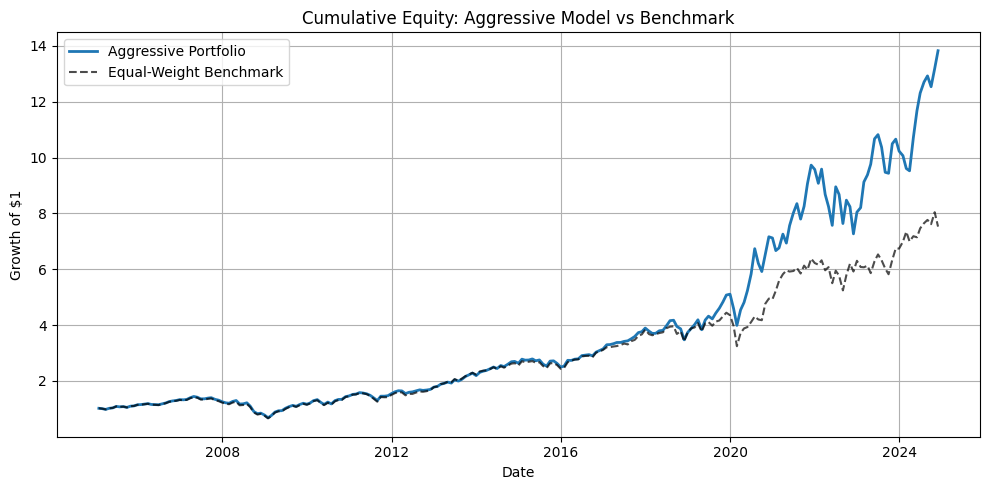

ROLLING_WINDOW = 24
GAMMA = 1.0
KAPPA = 0.005
LR = 0.1
STEPS = 1000
DEVICE = cpu
ret_panel_full shape = (300, 971)
universe hash sample = 300 [(Timestamp('2000-01-31 00:00:00'), []), (Timestamp('2000-02-29 00:00:00'), [])]
estimate_moments id = 136152711459552
optimize_weights id = 136152107546272


In [ ]:
# === Compare New Performance ===

import numpy as np
import matplotlib.pyplot as plt

port_ret_agg_arr = np.array(portfolio_returns_agg, dtype=float)
bench_ret_agg_arr = np.array(benchmark_returns_agg, dtype=float)

metrics_port_agg = performance_metrics(port_ret_agg_arr, freq=12)
metrics_bench_agg = performance_metrics(bench_ret_agg_arr, freq=12)

print("\n>>> Aggressive Portfolio:")
for k, v in metrics_port_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\n>>> Equal-Weight Benchmark:")
for k, v in metrics_bench_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual backtest dates
dates_agg = [d for d, _, _ in weight_history_agg]

plt.figure(figsize=(10, 5))
plt.plot(dates_agg, metrics_port_agg["equity_curve"], label="Aggressive Portfolio", linewidth=2)
plt.plot(dates_agg, metrics_bench_agg["equity_curve"], label="Equal-Weight Benchmark", linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative Equity: Aggressive Model vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

In [ ]:
# === RE-RUN FULL BACKTEST WITH AGGRESSIVE SETTINGS ===

import numpy as np
import pandas as pd
import torch

# 1. Update hyperparameters based on sanity check
GAMMA = 0.00001
KAPPA = 0.00001
LR = 0.1
STEPS = 1000

print(f"Re-running backtest with: GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")

portfolio_returns_agg = []
benchmark_returns_agg = []
weight_history_agg = []

# Previous portfolio stored by permno because the universe changes over time
w_prev_dict = None

# Loop over dates
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if too few assets
    if len(current_permnos) < 2:
        continue

    # Rolling estimation window
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Keep only stocks fully observed in the estimation window
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    if len(current_permnos) < 2:
        continue

    # Get next-month realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history_agg.append((date_t, current_permnos, w_t))

    # Realized portfolio return next month
    port_ret = float(np.dot(w_t, r_next_eval.values))

    # Equal-weight benchmark on same date-specific universe
    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    # Store returns
    portfolio_returns_agg.append(port_ret)
    benchmark_returns_agg.append(bench_ret)

print("Backtest complete.")
print("Number of backtest periods:", len(portfolio_returns_agg))

Re-running backtest with: GAMMA=1e-05, KAPPA=1e-05, LR=0.1, STEPS=1000
Backtest complete.
Number of backtest periods: 239



>>> Aggressive Portfolio:
  mean_ret_monthly: 0.0167
  vol_annual: 0.2437
  sharpe_annual: 0.8204
  max_drawdown: -0.5273
  cum_return: 28.1645

>>> Equal-Weight Benchmark:
  mean_ret_monthly: 0.0097
  vol_annual: 0.1691
  sharpe_annual: 0.6867
  max_drawdown: -0.5344
  cum_return: 6.5265


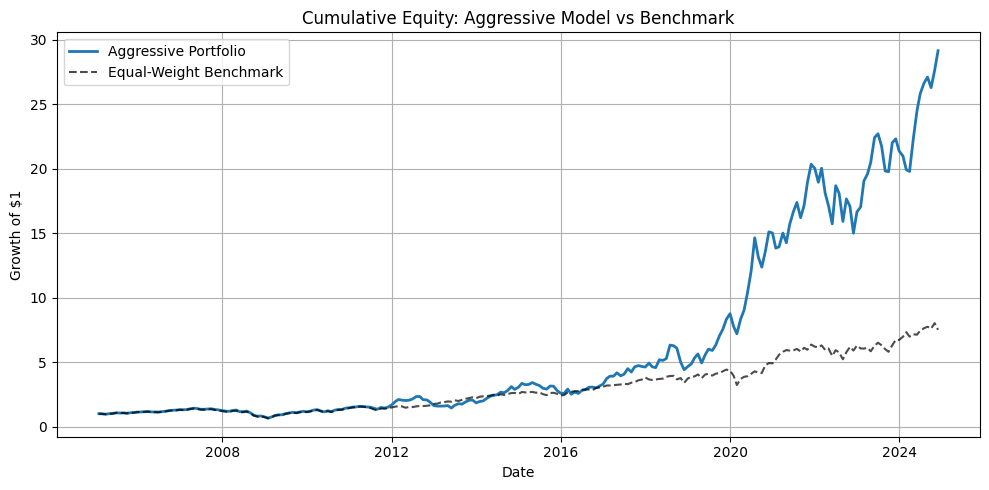

ROLLING_WINDOW = 24
GAMMA = 1e-05
KAPPA = 1e-05
LR = 0.1
STEPS = 1000
DEVICE = cpu
ret_panel_full shape = (300, 971)
universe hash sample = 300 [(Timestamp('2000-01-31 00:00:00'), []), (Timestamp('2000-02-29 00:00:00'), [])]
estimate_moments id = 136152711459552
optimize_weights id = 136152107546272


In [ ]:
# === Compare New Performance ===

import numpy as np
import matplotlib.pyplot as plt

port_ret_agg_arr = np.array(portfolio_returns_agg, dtype=float)
bench_ret_agg_arr = np.array(benchmark_returns_agg, dtype=float)

metrics_port_agg = performance_metrics(port_ret_agg_arr, freq=12)
metrics_bench_agg = performance_metrics(bench_ret_agg_arr, freq=12)

print("\n>>> Aggressive Portfolio:")
for k, v in metrics_port_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\n>>> Equal-Weight Benchmark:")
for k, v in metrics_bench_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual backtest dates
dates_agg = [d for d, _, _ in weight_history_agg]

plt.figure(figsize=(10, 5))
plt.plot(dates_agg, metrics_port_agg["equity_curve"], label="Aggressive Portfolio", linewidth=2)
plt.plot(dates_agg, metrics_bench_agg["equity_curve"], label="Equal-Weight Benchmark", linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative Equity: Aggressive Model vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

In [ ]:
# === RE-RUN FULL BACKTEST WITH AGGRESSIVE SETTINGS ===

import numpy as np
import pandas as pd
import torch

# 1. Update hyperparameters based on sanity check
GAMMA = 0.00001
KAPPA = 0.00001
LR = 0.1
STEPS = 5000

print(f"Re-running backtest with: GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")

portfolio_returns_agg = []
benchmark_returns_agg = []
weight_history_agg = []

# Previous portfolio stored by permno because the universe changes over time
w_prev_dict = None

# Loop over dates
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if too few assets
    if len(current_permnos) < 2:
        continue

    # Rolling estimation window
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Keep only stocks fully observed in the estimation window
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    if len(current_permnos) < 2:
        continue

    # Get next-month realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history_agg.append((date_t, current_permnos, w_t))

    # Realized portfolio return next month
    port_ret = float(np.dot(w_t, r_next_eval.values))

    # Equal-weight benchmark on same date-specific universe
    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    # Store returns
    portfolio_returns_agg.append(port_ret)
    benchmark_returns_agg.append(bench_ret)

print("Backtest complete.")
print("Number of backtest periods:", len(portfolio_returns_agg))

Re-running backtest with: GAMMA=1e-05, KAPPA=1e-05, LR=0.1, STEPS=5000
Backtest complete.
Number of backtest periods: 239



>>> Aggressive Portfolio:
  mean_ret_monthly: 0.0157
  vol_annual: 0.3723
  sharpe_annual: 0.5053
  max_drawdown: -0.8263
  cum_return: 9.7062

>>> Equal-Weight Benchmark:
  mean_ret_monthly: 0.0097
  vol_annual: 0.1691
  sharpe_annual: 0.6867
  max_drawdown: -0.5344
  cum_return: 6.5265


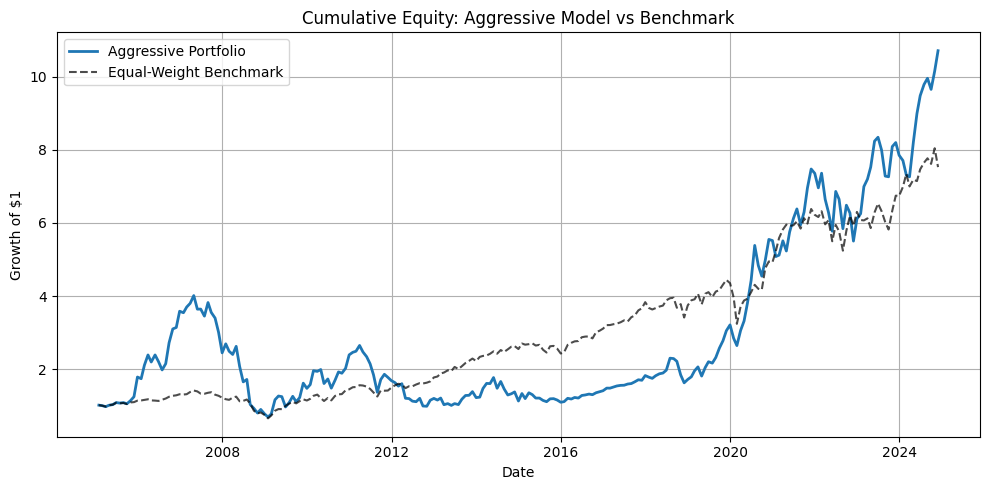

ROLLING_WINDOW = 24
GAMMA = 1e-05
KAPPA = 1e-05
LR = 0.1
STEPS = 5000
DEVICE = cpu
ret_panel_full shape = (300, 971)
universe hash sample = 300 [(Timestamp('2000-01-31 00:00:00'), []), (Timestamp('2000-02-29 00:00:00'), [])]
estimate_moments id = 136152711459552
optimize_weights id = 136152107546272


In [ ]:
# === Compare New Performance ===

import numpy as np
import matplotlib.pyplot as plt

port_ret_agg_arr = np.array(portfolio_returns_agg, dtype=float)
bench_ret_agg_arr = np.array(benchmark_returns_agg, dtype=float)

metrics_port_agg = performance_metrics(port_ret_agg_arr, freq=12)
metrics_bench_agg = performance_metrics(bench_ret_agg_arr, freq=12)

print("\n>>> Aggressive Portfolio:")
for k, v in metrics_port_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\n>>> Equal-Weight Benchmark:")
for k, v in metrics_bench_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual backtest dates
dates_agg = [d for d, _, _ in weight_history_agg]

plt.figure(figsize=(10, 5))
plt.plot(dates_agg, metrics_port_agg["equity_curve"], label="Aggressive Portfolio", linewidth=2)
plt.plot(dates_agg, metrics_bench_agg["equity_curve"], label="Equal-Weight Benchmark", linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative Equity: Aggressive Model vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

In [ ]:
# === RE-RUN FULL BACKTEST WITH AGGRESSIVE SETTINGS ===

import numpy as np
import pandas as pd
import torch

# 1. Update hyperparameters based on sanity check
GAMMA = 0.00001
KAPPA = 0.00001
LR = 0.01
STEPS = 5000

print(f"Re-running backtest with: GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")

portfolio_returns_agg = []
benchmark_returns_agg = []
weight_history_agg = []

# Previous portfolio stored by permno because the universe changes over time
w_prev_dict = None

# Loop over dates
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if too few assets
    if len(current_permnos) < 2:
        continue

    # Rolling estimation window
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Keep only stocks fully observed in the estimation window
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    if len(current_permnos) < 2:
        continue

    # Get next-month realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history_agg.append((date_t, current_permnos, w_t))

    # Realized portfolio return next month
    port_ret = float(np.dot(w_t, r_next_eval.values))

    # Equal-weight benchmark on same date-specific universe
    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    # Store returns
    portfolio_returns_agg.append(port_ret)
    benchmark_returns_agg.append(bench_ret)

print("Backtest complete.")
print("Number of backtest periods:", len(portfolio_returns_agg))

Re-running backtest with: GAMMA=1e-05, KAPPA=1e-05, LR=0.01, STEPS=5000
Backtest complete.
Number of backtest periods: 239



>>> Aggressive Portfolio:
  mean_ret_monthly: 0.0096
  vol_annual: 0.1638
  sharpe_annual: 0.7060
  max_drawdown: -0.5273
  cum_return: 6.5836

>>> Equal-Weight Benchmark:
  mean_ret_monthly: 0.0097
  vol_annual: 0.1691
  sharpe_annual: 0.6867
  max_drawdown: -0.5344
  cum_return: 6.5265


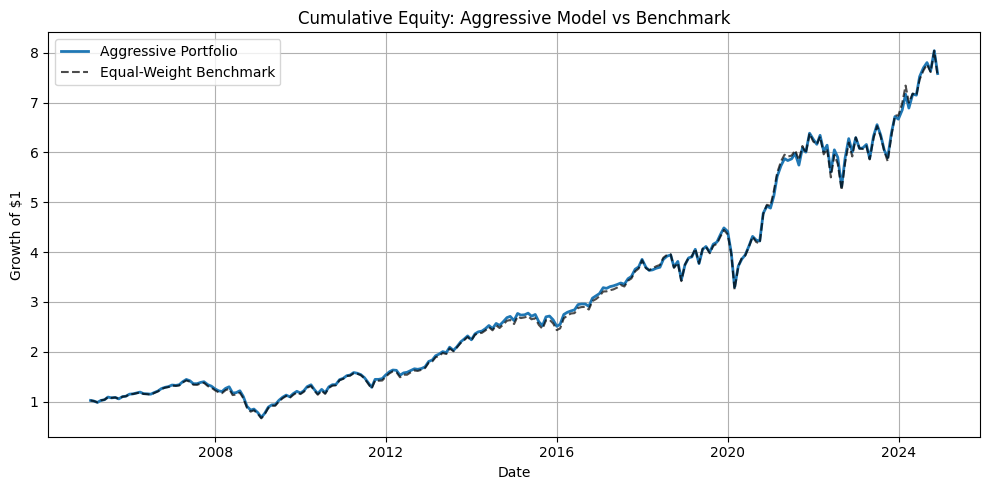

ROLLING_WINDOW = 24
GAMMA = 1e-05
KAPPA = 1e-05
LR = 0.01
STEPS = 5000
DEVICE = cpu
ret_panel_full shape = (300, 971)
universe hash sample = 300 [(Timestamp('2000-01-31 00:00:00'), []), (Timestamp('2000-02-29 00:00:00'), [])]
estimate_moments id = 136152711459552
optimize_weights id = 136152107546272


In [ ]:
# === Compare New Performance ===

import numpy as np
import matplotlib.pyplot as plt

port_ret_agg_arr = np.array(portfolio_returns_agg, dtype=float)
bench_ret_agg_arr = np.array(benchmark_returns_agg, dtype=float)

metrics_port_agg = performance_metrics(port_ret_agg_arr, freq=12)
metrics_bench_agg = performance_metrics(bench_ret_agg_arr, freq=12)

print("\n>>> Aggressive Portfolio:")
for k, v in metrics_port_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\n>>> Equal-Weight Benchmark:")
for k, v in metrics_bench_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual backtest dates
dates_agg = [d for d, _, _ in weight_history_agg]

plt.figure(figsize=(10, 5))
plt.plot(dates_agg, metrics_port_agg["equity_curve"], label="Aggressive Portfolio", linewidth=2)
plt.plot(dates_agg, metrics_bench_agg["equity_curve"], label="Equal-Weight Benchmark", linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative Equity: Aggressive Model vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

In [ ]:
# === RE-RUN FULL BACKTEST WITH AGGRESSIVE SETTINGS ===

import numpy as np
import pandas as pd
import torch

# 1. Update hyperparameters based on sanity check
GAMMA = 0.00001
KAPPA = 0.00001
LR = 0.1
STEPS = 500

print(f"Re-running backtest with: GAMMA={GAMMA}, KAPPA={KAPPA}, LR={LR}, STEPS={STEPS}")

portfolio_returns_agg = []
benchmark_returns_agg = []
weight_history_agg = []

# Previous portfolio stored by permno because the universe changes over time
w_prev_dict = None

# Loop over dates
for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
    date_t = dates[t_idx]
    date_next = dates[t_idx + 1]

    # Eligible stocks at time t
    current_permnos = eligible_universe_by_date.get(date_t, [])

    # Skip if too few assets
    if len(current_permnos) < 2:
        continue

    # Rolling estimation window
    window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
    window_ret = ret_panel_full.loc[window_dates, current_permnos]

    # Keep only stocks fully observed in the estimation window
    valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
    window_ret = window_ret[valid_cols]
    current_permnos = list(valid_cols)

    if len(current_permnos) < 2:
        continue

    # Get next-month realized returns for evaluation only
    r_next = ret_panel_full.loc[date_next, current_permnos]
    r_next_eval = r_next.fillna(0.0)

    # Estimate moments
    mu_t, Sigma_t = estimate_moments(window_ret)

    # Align previous weights to current universe
    w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)

    # Optimize
    w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

    # Store current weights by permno
    w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}

    # Save weight history
    weight_history_agg.append((date_t, current_permnos, w_t))

    # Realized portfolio return next month
    port_ret = float(np.dot(w_t, r_next_eval.values))

    # Equal-weight benchmark on same date-specific universe
    N_t = len(current_permnos)
    ew = np.ones(N_t) / N_t
    bench_ret = float(np.dot(ew, r_next_eval.values))

    # Store returns
    portfolio_returns_agg.append(port_ret)
    benchmark_returns_agg.append(bench_ret)

print("Backtest complete.")
print("Number of backtest periods:", len(portfolio_returns_agg))

Re-running backtest with: GAMMA=1e-05, KAPPA=1e-05, LR=0.1, STEPS=500
Backtest complete.
Number of backtest periods: 239



>>> Aggressive Portfolio:
  mean_ret_monthly: 0.0096
  vol_annual: 0.1639
  sharpe_annual: 0.7050
  max_drawdown: -0.5271
  cum_return: 6.5632

>>> Equal-Weight Benchmark:
  mean_ret_monthly: 0.0097
  vol_annual: 0.1691
  sharpe_annual: 0.6867
  max_drawdown: -0.5344
  cum_return: 6.5265


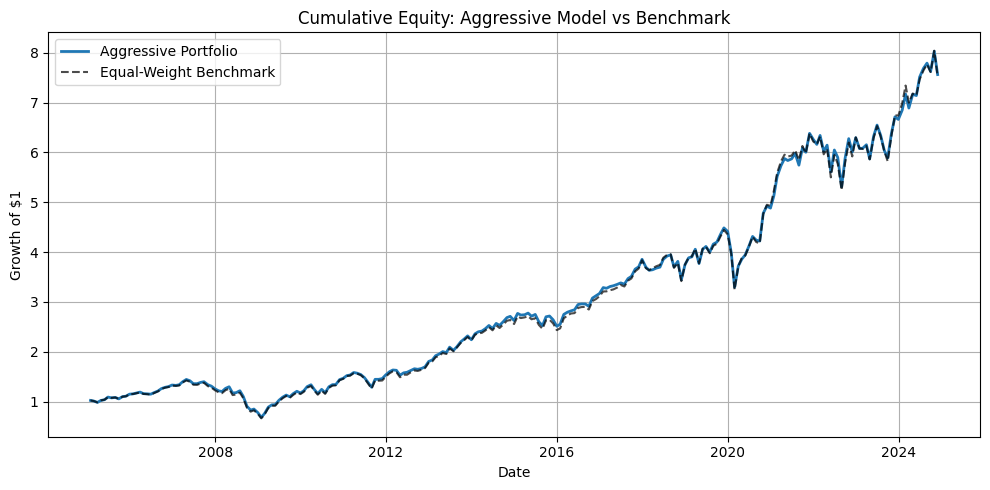

ROLLING_WINDOW = 24
GAMMA = 1e-05
KAPPA = 1e-05
LR = 0.1
STEPS = 500
DEVICE = cpu
ret_panel_full shape = (300, 971)
universe hash sample = 300 [(Timestamp('2000-01-31 00:00:00'), []), (Timestamp('2000-02-29 00:00:00'), [])]
estimate_moments id = 136152711459552
optimize_weights id = 136152107546272


In [ ]:
# === Compare New Performance ===

import numpy as np
import matplotlib.pyplot as plt

port_ret_agg_arr = np.array(portfolio_returns_agg, dtype=float)
bench_ret_agg_arr = np.array(benchmark_returns_agg, dtype=float)

metrics_port_agg = performance_metrics(port_ret_agg_arr, freq=12)
metrics_bench_agg = performance_metrics(bench_ret_agg_arr, freq=12)

print("\n>>> Aggressive Portfolio:")
for k, v in metrics_port_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\n>>> Equal-Weight Benchmark:")
for k, v in metrics_bench_agg.items():
    if k != "equity_curve":
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Use actual backtest dates
dates_agg = [d for d, _, _ in weight_history_agg]

plt.figure(figsize=(10, 5))
plt.plot(dates_agg, metrics_port_agg["equity_curve"], label="Aggressive Portfolio", linewidth=2)
plt.plot(dates_agg, metrics_bench_agg["equity_curve"], label="Equal-Weight Benchmark", linestyle="--", color="black", alpha=0.7)
plt.title("Cumulative Equity: Aggressive Model vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("ROLLING_WINDOW =", ROLLING_WINDOW)
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)
print("DEVICE =", DEVICE)
print("ret_panel_full shape =", ret_panel_full.shape)
print("universe hash sample =", len(eligible_universe_by_date), list(eligible_universe_by_date.items())[:2])
print("estimate_moments id =", id(estimate_moments))
print("optimize_weights id =", id(optimize_weights))

In [ ]:
# === GRID SEARCH OVER LEARNING RATES WITH FIXED AGGRESSIVE PARAMETERS ===

import numpy as np
import pandas as pd

# Fixed parameters from your aggressive run
GAMMA = 0.00001
KAPPA = 0.00001
STEPS = 1000

# Grid over learning rates
lr_grid = [0.001, 0.003, 0.01, 0.03, 0.1, 1.0]

print(f"Fixed settings: GAMMA={GAMMA}, KAPPA={KAPPA}, STEPS={STEPS}")
print("LR grid:", lr_grid)

lr_results = []

for lr_val in lr_grid:
    LR = lr_val
    print(f"\nRunning backtest with LR={LR}")

    portfolio_returns_agg = []
    benchmark_returns_agg = []
    weight_history_agg = []

    w_prev_dict = None

    for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
        date_t = dates[t_idx]
        date_next = dates[t_idx + 1]

        current_permnos = eligible_universe_by_date.get(date_t, [])
        if len(current_permnos) < 2:
            continue

        window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
        window_ret = ret_panel_full.loc[window_dates, current_permnos]

        valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
        window_ret = window_ret[valid_cols]
        current_permnos = list(valid_cols)

        if len(current_permnos) < 2:
            continue

        r_next = ret_panel_full.loc[date_next, current_permnos]
        r_next_eval = r_next.fillna(0.0)

        mu_t, Sigma_t = estimate_moments(window_ret)
        w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)
        w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

        w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}
        weight_history_agg.append((date_t, current_permnos, w_t))

        port_ret = float(np.dot(w_t, r_next_eval.values))

        N_t = len(current_permnos)
        ew = np.ones(N_t) / N_t
        bench_ret = float(np.dot(ew, r_next_eval.values))

        portfolio_returns_agg.append(port_ret)
        benchmark_returns_agg.append(bench_ret)

    metrics_port = performance_metrics(np.array(portfolio_returns_agg), freq=12)
    metrics_bench = performance_metrics(np.array(benchmark_returns_agg), freq=12)

    lr_results.append({
        "LR": lr_val,
        "mean_ret_monthly": metrics_port["mean_ret_monthly"],
        "vol_annual": metrics_port["vol_annual"],
        "sharpe_annual": metrics_port["sharpe_annual"],
        "max_drawdown": metrics_port["max_drawdown"],
        "cum_return": metrics_port["cum_return"],
        "bench_sharpe_annual": metrics_bench["sharpe_annual"],
        "n_periods": len(portfolio_returns_agg),
    })

lr_results_df = pd.DataFrame(lr_results).sort_values(
    by=["sharpe_annual", "cum_return"],
    ascending=False
).reset_index(drop=True)

print("\nLearning rate results:")
display(lr_results_df)

best_lr = lr_results_df.loc[0, "LR"]
print(f"\nBest LR: {best_lr}")

Fixed settings: GAMMA=1e-05, KAPPA=1e-05, STEPS=1000
LR grid: [0.001, 0.003, 0.01, 0.03, 0.1, 1.0]

Running backtest with LR=0.001

Running backtest with LR=0.003

Running backtest with LR=0.01

Running backtest with LR=0.03

Running backtest with LR=0.1

Running backtest with LR=1.0

Learning rate results:


,LR,mean_ret_monthly,vol_annual,sharpe_annual,max_drawdown,cum_return,bench_sharpe_annual,n_periods
0,0.100,0.016659,0.243674,0.820393,-0.527294,28.164497,0.68669,239
1,0.030,0.009537,0.164267,0.696678,-0.527793,6.391915,0.68669,239
2,0.003,0.009554,0.164679,0.696179,-0.529187,6.411836,0.68669,239
3,0.010,0.009545,0.164541,0.696122,-0.528752,6.399780,0.68669,239
4,0.001,0.009555,0.164711,0.696106,-0.529265,6.412552,0.68669,239
5,1.000,0.010962,0.387286,0.339657,-0.826479,2.174224,0.68669,239



Best LR: 0.1


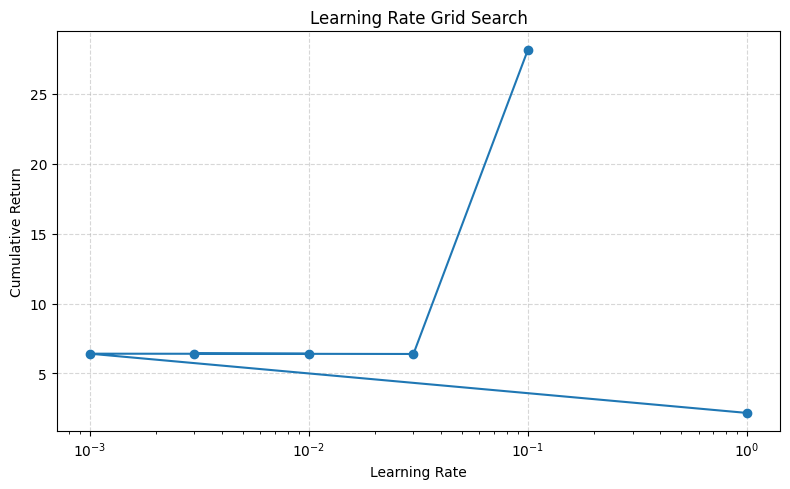

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(lr_results_df["LR"], lr_results_df["cum_return"], marker="o")
plt.xscale("log")
plt.xlabel("Learning Rate")
plt.ylabel("Cumulative Return")
plt.title("Learning Rate Grid Search")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# === GRID SEARCH OVER LR AND STEPS WITH FIXED AGGRESSIVE PARAMETERS ===

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

# Fixed economic parameters
GAMMA = 0.00001
KAPPA = 0.00001

# Grids
lr_grid = [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]
steps_grid = [100, 300, 1000, 3000, 5000]

print(f"Fixed settings: GAMMA={GAMMA}, KAPPA={KAPPA}")
print("LR grid:", lr_grid)
print("STEPS grid:", steps_grid)

grid_results = []

for run_idx, (lr_val, steps_val) in enumerate(product(lr_grid, steps_grid), 1):
    LR = lr_val
    STEPS = steps_val

    print(f"[{run_idx:02d}/{len(lr_grid)*len(steps_grid)}] Running LR={LR}, STEPS={STEPS}")

    portfolio_returns_tmp = []
    benchmark_returns_tmp = []
    weight_history_tmp = []

    w_prev_dict = None

    for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
        date_t = dates[t_idx]
        date_next = dates[t_idx + 1]

        current_permnos = eligible_universe_by_date.get(date_t, [])
        if len(current_permnos) < 2:
            continue

        window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
        window_ret = ret_panel_full.loc[window_dates, current_permnos]

        valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
        window_ret = window_ret[valid_cols]
        current_permnos = list(valid_cols)

        if len(current_permnos) < 2:
            continue

        r_next = ret_panel_full.loc[date_next, current_permnos]
        r_next_eval = r_next.fillna(0.0)

        mu_t, Sigma_t = estimate_moments(window_ret)
        w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)
        w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

        w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}
        weight_history_tmp.append((date_t, current_permnos, w_t))

        port_ret = float(np.dot(w_t, r_next_eval.values))

        N_t = len(current_permnos)
        ew = np.ones(N_t) / N_t
        bench_ret = float(np.dot(ew, r_next_eval.values))

        portfolio_returns_tmp.append(port_ret)
        benchmark_returns_tmp.append(bench_ret)

    port_arr = np.array(portfolio_returns_tmp, dtype=float)
    bench_arr = np.array(benchmark_returns_tmp, dtype=float)

    metrics_port = performance_metrics(port_arr, freq=12)
    metrics_bench = performance_metrics(bench_arr, freq=12)

    grid_results.append({
        "LR": lr_val,
        "STEPS": steps_val,
        "n_periods": len(port_arr),
        "mean_ret_monthly": metrics_port["mean_ret_monthly"],
        "vol_annual": metrics_port["vol_annual"],
        "sharpe_annual": metrics_port["sharpe_annual"],
        "max_drawdown": metrics_port["max_drawdown"],
        "cum_return": metrics_port["cum_return"],
        "bench_sharpe_annual": metrics_bench["sharpe_annual"],
        "port_returns": port_arr,
        "bench_returns": bench_arr,
        "weight_history": weight_history_tmp,
    })

grid_results_df = pd.DataFrame([
    {
        "LR": r["LR"],
        "STEPS": r["STEPS"],
        "n_periods": r["n_periods"],
        "mean_ret_monthly": r["mean_ret_monthly"],
        "vol_annual": r["vol_annual"],
        "sharpe_annual": r["sharpe_annual"],
        "max_drawdown": r["max_drawdown"],
        "cum_return": r["cum_return"],
        "bench_sharpe_annual": r["bench_sharpe_annual"],
    }
    for r in grid_results
])

grid_results_df = grid_results_df.sort_values(
    by=["sharpe_annual", "cum_return"],
    ascending=False
).reset_index(drop=True)

print("\nTop results:")
display(grid_results_df)

best_lr = grid_results_df.loc[0, "LR"]
best_steps = int(grid_results_df.loc[0, "STEPS"])

print(f"\nBest LR: {best_lr}")
print(f"Best STEPS: {best_steps}")

best_lr_steps_result = max(
    grid_results,
    key=lambda r: (-np.inf if np.isnan(r["sharpe_annual"]) else r["sharpe_annual"], r["cum_return"])
)

# Update globals
LR = best_lr
STEPS = best_steps

print("\nUpdated globals:")
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR    =", LR)
print("STEPS =", STEPS)

Fixed settings: GAMMA=1e-05, KAPPA=1e-05
LR grid: [0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]
STEPS grid: [100, 300, 1000, 3000, 5000]
[01/30] Running LR=0.0003, STEPS=100
[02/30] Running LR=0.0003, STEPS=300
[03/30] Running LR=0.0003, STEPS=1000
[04/30] Running LR=0.0003, STEPS=3000
[05/30] Running LR=0.0003, STEPS=5000
[06/30] Running LR=0.001, STEPS=100
[07/30] Running LR=0.001, STEPS=300
[08/30] Running LR=0.001, STEPS=1000
[09/30] Running LR=0.001, STEPS=3000
[10/30] Running LR=0.001, STEPS=5000
[11/30] Running LR=0.003, STEPS=100
[12/30] Running LR=0.003, STEPS=300
[13/30] Running LR=0.003, STEPS=1000
[14/30] Running LR=0.003, STEPS=3000
[15/30] Running LR=0.003, STEPS=5000
[16/30] Running LR=0.01, STEPS=100
[17/30] Running LR=0.01, STEPS=300
[18/30] Running LR=0.01, STEPS=1000
[19/30] Running LR=0.01, STEPS=3000
[20/30] Running LR=0.01, STEPS=5000
[21/30] Running LR=0.03, STEPS=100
[22/30] Running LR=0.03, STEPS=300
[23/30] Running LR=0.03, STEPS=1000
[24/30] Running LR=0.03, STEPS=

,LR,STEPS,n_periods,mean_ret_monthly,vol_annual,sharpe_annual,max_drawdown,cum_return,bench_sharpe_annual
0,0.1000,1000,239,0.016659,0.243674,0.820393,-0.527294,28.164497,0.68669
1,0.0300,3000,239,0.015120,0.232239,0.781281,-0.526868,20.400164,0.68669
2,0.0300,5000,239,0.016617,0.273711,0.728519,-0.760052,23.217351,0.68669
3,0.0100,5000,239,0.009639,0.163824,0.706015,-0.527263,6.583619,0.68669
4,0.0100,3000,239,0.009536,0.164246,0.696723,-0.527879,6.391368,0.68669
5,0.0300,1000,239,0.009537,0.164267,0.696678,-0.527793,6.391915,0.68669
6,0.1000,300,239,0.009537,0.164275,0.696628,-0.527784,6.391307,0.68669
7,0.0030,5000,239,0.009550,0.164565,0.696349,-0.528898,6.407088,0.68669
8,0.0030,3000,239,0.009552,0.164622,0.696261,-0.529034,6.409359,0.68669
9,0.0030,1000,239,0.009554,0.164679,0.696179,-0.529187,6.411836,0.68669



Best LR: 0.1
Best STEPS: 1000

Updated globals:
GAMMA = 1e-05
KAPPA = 1e-05
LR    = 0.1
STEPS = 1000


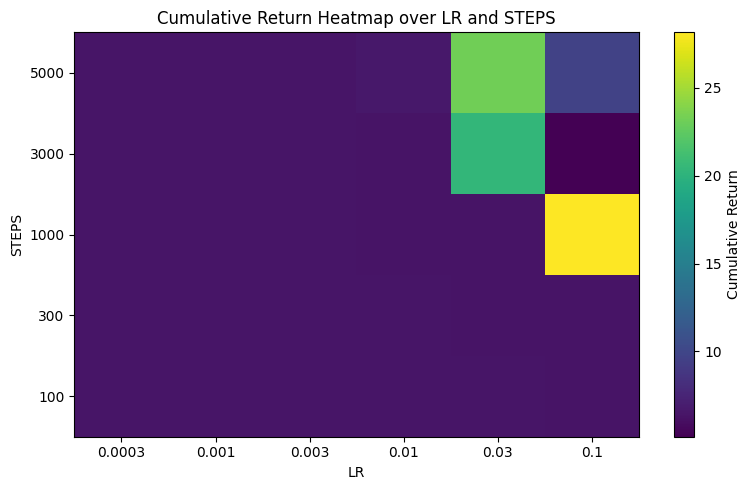

In [ ]:
# === HEATMAP: CUMULATIVE RETURN OVER LR x STEPS ===

heatmap_df = grid_results_df.pivot(index="STEPS", columns="LR", values="cum_return")

plt.figure(figsize=(8, 5))
im = plt.imshow(heatmap_df.values, aspect="auto", origin="lower")
plt.colorbar(im, label="Cumulative Return")

plt.xticks(range(len(heatmap_df.columns)), [str(x) for x in heatmap_df.columns])
plt.yticks(range(len(heatmap_df.index)), [str(x) for x in heatmap_df.index])

plt.xlabel("LR")
plt.ylabel("STEPS")
plt.title("Cumulative Return Heatmap over LR and STEPS")
plt.tight_layout()
plt.show()

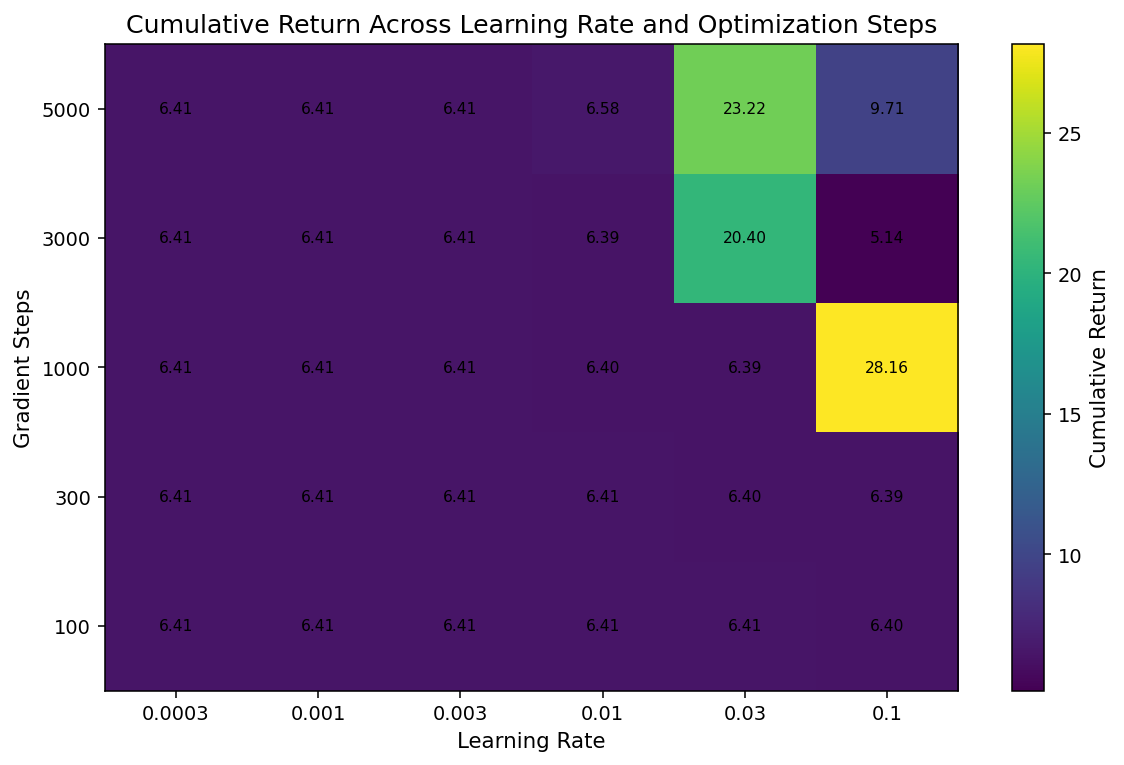

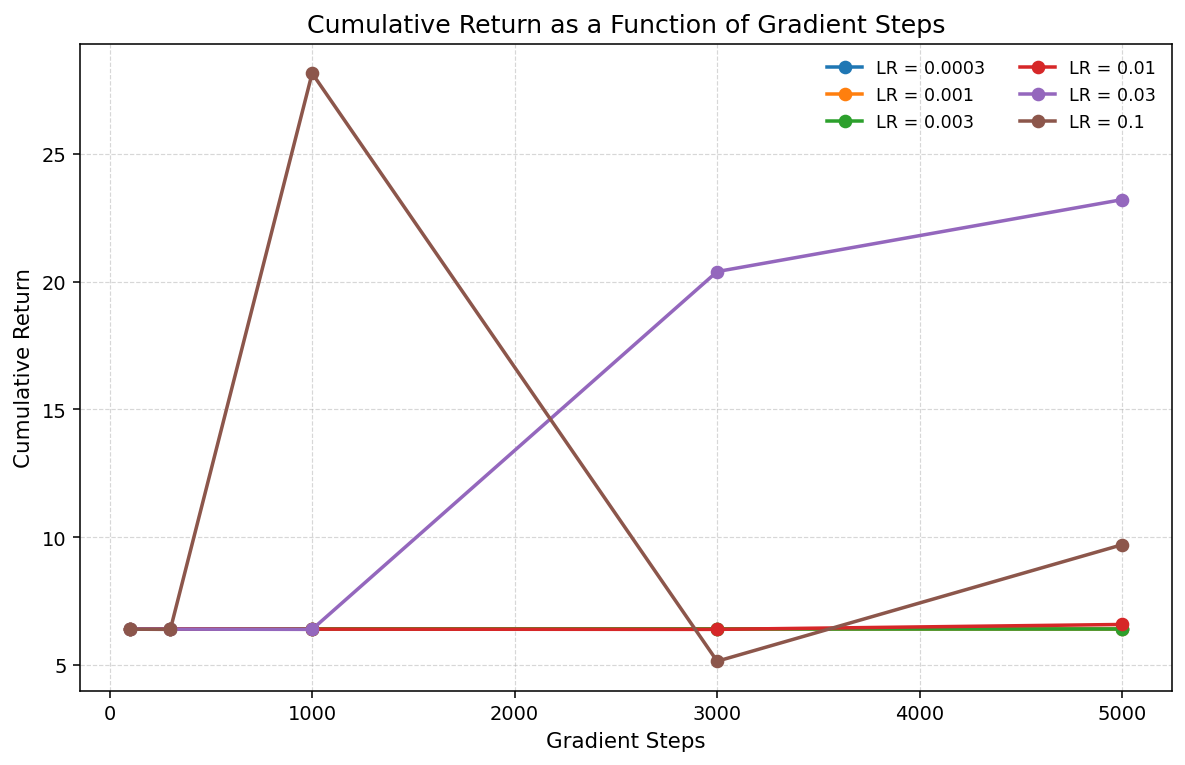

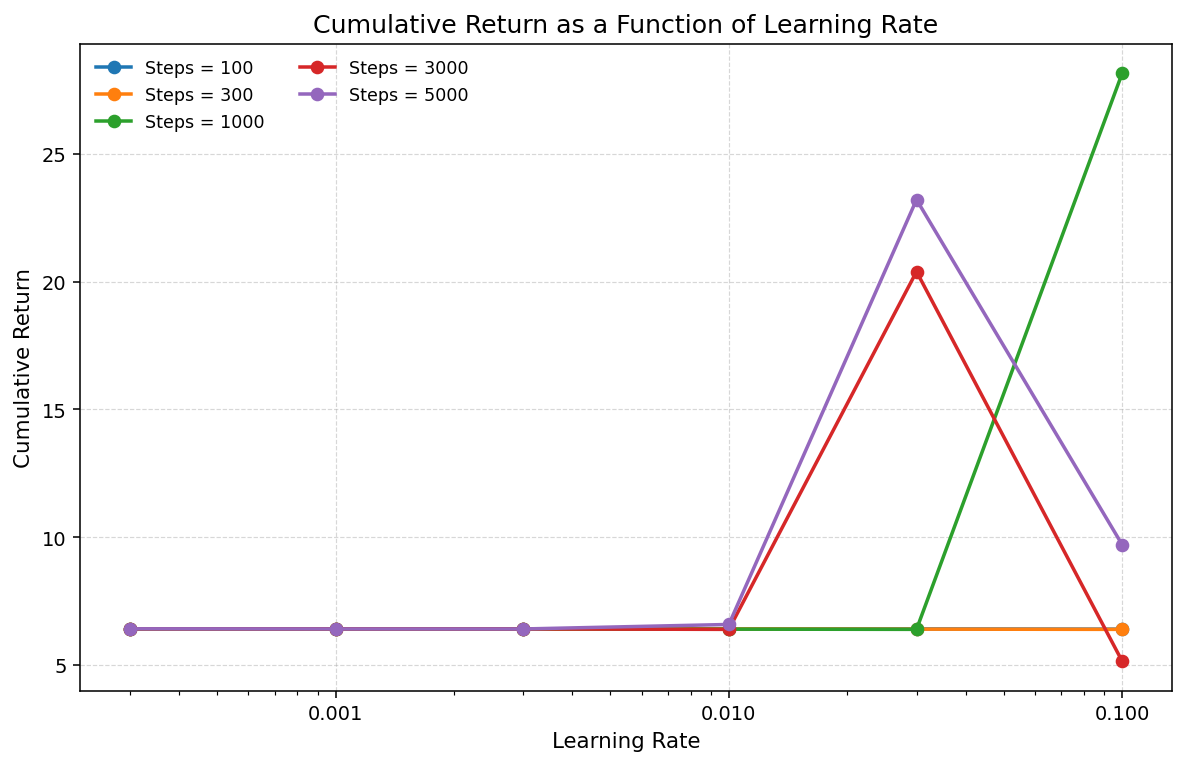

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# -----------------------------
# PREP
# -----------------------------
df = grid_results_df.copy()

# Make sure ordering is numerical and clean
df["LR"] = df["LR"].astype(float)
df["STEPS"] = df["STEPS"].astype(int)

lr_vals = sorted(df["LR"].unique())
step_vals = sorted(df["STEPS"].unique())

heatmap_df = df.pivot(index="STEPS", columns="LR", values="cum_return")
heatmap_df = heatmap_df.loc[step_vals, lr_vals]

# -----------------------------
# GLOBAL STYLE
# -----------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 140
})

# -----------------------------
# FIGURE 1: HEATMAP
# -----------------------------
fig, ax = plt.subplots(figsize=(8.6, 5.6))

im = ax.imshow(
    heatmap_df.values,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Cumulative Return", rotation=90)

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels([f"{x:g}" for x in heatmap_df.columns])
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels([f"{y:d}" for y in heatmap_df.index])

ax.set_xlabel("Learning Rate")
ax.set_ylabel("Gradient Steps")
ax.set_title("Cumulative Return Across Learning Rate and Optimization Steps")

# Optional: annotate cells
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

fig.tight_layout()
plt.show()


# -----------------------------
# FIGURE 2: ONE CURVE PER LR
# x-axis = STEPS
# -----------------------------
fig, ax = plt.subplots(figsize=(8.6, 5.6))

for lr in lr_vals:
    sub = df[df["LR"] == lr].sort_values("STEPS")
    ax.plot(
        sub["STEPS"],
        sub["cum_return"],
        marker="o",
        linewidth=1.8,
        label=f"LR = {lr:g}"
    )

ax.set_xlabel("Gradient Steps")
ax.set_ylabel("Cumulative Return")
ax.set_title("Cumulative Return as a Function of Gradient Steps")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


# -----------------------------
# FIGURE 3: ONE CURVE PER STEPS
# x-axis = LR (log scale)
# -----------------------------
fig, ax = plt.subplots(figsize=(8.6, 5.6))

for steps in step_vals:
    sub = df[df["STEPS"] == steps].sort_values("LR")
    ax.plot(
        sub["LR"],
        sub["cum_return"],
        marker="o",
        linewidth=1.8,
        label=f"Steps = {steps}"
    )

ax.set_xscale("log")
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Cumulative Return")
ax.set_title("Cumulative Return as a Function of Learning Rate")
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()

In [ ]:
# === GRID SEARCH OVER 5 GAMMA VALUES x 5 KAPPA VALUES ===

import numpy as np
import pandas as pd
import torch
from itertools import product

# -----------------------------
# 1. Choose grids
# -----------------------------
gamma_grid = np.logspace(-3, 1, 5)   # 0.001, 0.01, 0.1, 1, 10
kappa_grid = np.logspace(-5, -1, 5)  # 1e-5, 1e-4, 1e-3, 1e-2, 1e-1

print("gamma_grid =", gamma_grid)
print("kappa_grid =", kappa_grid)

# Save original globals
GAMMA_orig = GAMMA
KAPPA_orig = KAPPA
LR_orig = LR
STEPS_orig = STEPS

# Keep solver settings fixed during search
LR = 0.1
STEPS = 1000

# -----------------------------
# 2. Reusable backtest
# -----------------------------
def run_backtest_for_params(gamma_val, kappa_val):
    global GAMMA, KAPPA

    GAMMA = float(gamma_val)
    KAPPA = float(kappa_val)

    portfolio_returns_grid = []
    benchmark_returns_grid = []
    weight_history_grid = []

    w_prev_dict = None

    for t_idx in range(ROLLING_WINDOW, len(dates) - 1):
        date_t = dates[t_idx]
        date_next = dates[t_idx + 1]

        current_permnos = eligible_universe_by_date.get(date_t, [])

        if len(current_permnos) < 2:
            continue

        window_dates = dates[t_idx - ROLLING_WINDOW:t_idx]
        window_ret = ret_panel_full.loc[window_dates, current_permnos]

        valid_cols = window_ret.columns[window_ret.notna().all(axis=0)]
        window_ret = window_ret[valid_cols]
        current_permnos = list(valid_cols)

        if len(current_permnos) < 2:
            continue

        r_next = ret_panel_full.loc[date_next, current_permnos]
        r_next_eval = r_next.fillna(0.0)

        mu_t, Sigma_t = estimate_moments(window_ret)
        w_prev = get_prev_weights_for_current_universe(current_permnos, w_prev_dict)
        w_t = optimize_weights(mu_t, Sigma_t, w_prev=w_prev)

        w_prev_dict = {p: w for p, w in zip(current_permnos, w_t)}
        weight_history_grid.append((date_t, current_permnos, w_t))

        port_ret = float(np.dot(w_t, r_next_eval.values))

        N_t = len(current_permnos)
        ew = np.ones(N_t) / N_t
        bench_ret = float(np.dot(ew, r_next_eval.values))

        portfolio_returns_grid.append(port_ret)
        benchmark_returns_grid.append(bench_ret)

    port_arr = np.array(portfolio_returns_grid, dtype=float)
    bench_arr = np.array(benchmark_returns_grid, dtype=float)

    metrics_port = performance_metrics(port_arr, freq=12)
    metrics_bench = performance_metrics(bench_arr, freq=12)

    return {
        "gamma": gamma_val,
        "kappa": kappa_val,
        "n_periods": len(port_arr),
        "port_returns": port_arr,
        "bench_returns": bench_arr,
        "weight_history": weight_history_grid,
        "mean_ret_monthly": metrics_port["mean_ret_monthly"],
        "vol_annual": metrics_port["vol_annual"],
        "sharpe_annual": metrics_port["sharpe_annual"],
        "max_drawdown": metrics_port["max_drawdown"],
        "cum_return": metrics_port["cum_return"],
        "bench_sharpe_annual": metrics_bench["sharpe_annual"],
        "bench_cum_return": metrics_bench["cum_return"],
    }

# -----------------------------
# 3. Run the 5x5 grid
# -----------------------------
results = []

total_runs = len(gamma_grid) * len(kappa_grid)
run_idx = 0

for gamma_val, kappa_val in product(gamma_grid, kappa_grid):
    run_idx += 1
    print(f"[{run_idx:02d}/{total_runs}] Running gamma={gamma_val:.6f}, kappa={kappa_val:.6f}")

    out = run_backtest_for_params(gamma_val, kappa_val)
    results.append(out)

results_df = pd.DataFrame([
    {
        "gamma": r["gamma"],
        "kappa": r["kappa"],
        "n_periods": r["n_periods"],
        "mean_ret_monthly": r["mean_ret_monthly"],
        "vol_annual": r["vol_annual"],
        "sharpe_annual": r["sharpe_annual"],
        "max_drawdown": r["max_drawdown"],
        "cum_return": r["cum_return"],
        "bench_sharpe_annual": r["bench_sharpe_annual"],
        "bench_cum_return": r["bench_cum_return"],
    }
    for r in results
])

results_df_sorted = results_df.sort_values(
    by=["sharpe_annual", "cum_return"],
    ascending=False
).reset_index(drop=True)

print("\nTop parameter combinations:")
display(results_df_sorted)

best_row = results_df_sorted.iloc[0]
best_gamma = float(best_row["gamma"])
best_kappa = float(best_row["kappa"])

print("\nBest parameters found:")
print("GAMMA =", best_gamma)
print("KAPPA =", best_kappa)

best_result = max(
    results,
    key=lambda r: (-np.inf if np.isnan(r["sharpe_annual"]) else r["sharpe_annual"], r["cum_return"])
)

GAMMA = best_gamma
KAPPA = best_kappa

print("\nGlobals updated to best parameters.")
print("GAMMA =", GAMMA)
print("KAPPA =", KAPPA)
print("LR =", LR)
print("STEPS =", STEPS)

gamma_grid = [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01]
kappa_grid = [1.e-05 1.e-04 1.e-03 1.e-02 1.e-01]
[01/25] Running gamma=0.001000, kappa=0.000010
[02/25] Running gamma=0.001000, kappa=0.000100
[03/25] Running gamma=0.001000, kappa=0.001000
[04/25] Running gamma=0.001000, kappa=0.010000
[05/25] Running gamma=0.001000, kappa=0.100000
[06/25] Running gamma=0.010000, kappa=0.000010
[07/25] Running gamma=0.010000, kappa=0.000100
[08/25] Running gamma=0.010000, kappa=0.001000
[09/25] Running gamma=0.010000, kappa=0.010000
[10/25] Running gamma=0.010000, kappa=0.100000
[11/25] Running gamma=0.100000, kappa=0.000010
[12/25] Running gamma=0.100000, kappa=0.000100
[13/25] Running gamma=0.100000, kappa=0.001000
[14/25] Running gamma=0.100000, kappa=0.010000
[15/25] Running gamma=0.100000, kappa=0.100000
[16/25] Running gamma=1.000000, kappa=0.000010
[17/25] Running gamma=1.000000, kappa=0.000100
[18/25] Running gamma=1.000000, kappa=0.001000
[19/25] Running gamma=1.000000, kappa=0.010000
[20/25]

,gamma,kappa,n_periods,mean_ret_monthly,vol_annual,sharpe_annual,max_drawdown,cum_return,bench_sharpe_annual,bench_cum_return
0,0.001,0.00001,239,0.016658,0.243670,0.820376,-0.527293,28.160673,0.68669,6.526503
1,0.010,0.00001,239,0.016653,0.243630,0.820236,-0.527282,28.127908,0.68669,6.526503
2,0.100,0.00001,239,0.016597,0.243204,0.818928,-0.527151,27.804617,0.68669,6.526503
3,0.001,0.00010,239,0.016613,0.243462,0.818838,-0.527306,27.876726,0.68669,6.526503
4,0.010,0.00010,239,0.016607,0.243420,0.818700,-0.527293,27.843797,0.68669,6.526503
5,0.100,0.00010,239,0.016547,0.242958,0.817283,-0.527151,27.497902,0.68669,6.526503
6,0.001,0.00100,239,0.015979,0.240521,0.797233,-0.527367,24.203945,0.68669,6.526503
7,0.010,0.00100,239,0.015972,0.240466,0.797041,-0.527352,24.165779,0.68669,6.526503
8,0.100,0.00100,239,0.015900,0.239883,0.795374,-0.527221,23.809431,0.68669,6.526503
9,1.000,0.00001,239,0.014547,0.226675,0.770121,-0.525775,18.132436,0.68669,6.526503



Best parameters found:
GAMMA = 0.001
KAPPA = 1e-05

Globals updated to best parameters.
GAMMA = 0.001
KAPPA = 1e-05
LR = 0.1
STEPS = 1000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data for seaborn heatmap
heatmap_data = results_df.pivot(index='kappa', columns='gamma', values='sharpe_annual')

# Create a visually appealing heatmap
plt.figure(figsize=(10, 7))
sns.set_theme(style='white')

ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Annual Sharpe Ratio'}
)

# Format the axis labels to be more readable
ax.set_xticklabels([f'{float(x):.3g}' for x in heatmap_data.columns])
ax.set_yticklabels([f'{float(x):.3g}' for x in heatmap_data.index])

plt.title('Optimization Grid Search: Annual Sharpe Ratio', fontsize=15, pad=20)
plt.xlabel('Risk Aversion (GAMMA)', fontsize=12)
plt.ylabel('Turnover Penalty (KAPPA)', fontsize=12)

plt.tight_layout()
plt.show()

NameError: name 'results_df' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Best result was stored in 'best_result' during the grid search
port_ret_best = best_result['port_returns']
bench_ret_best = best_result['bench_returns']

metrics_port_best = performance_metrics(port_ret_best, freq=12)
metrics_bench_best = performance_metrics(bench_ret_best, freq=12)

print(f"\n>>> Best Portfolio (GAMMA={best_gamma}, KAPPA={best_kappa}):")
for k, v in metrics_port_best.items():
    if k != 'equity_curve':
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

print("\n>>> Equal-Weight Benchmark:")
for k, v in metrics_bench_best.items():
    if k != 'equity_curve':
        print(f"  {k}: {v:.4f}" if not np.isnan(v) else f"  {k}: nan")

# Extract dates from weight history of the best run
best_dates = [x[0] for x in best_result['weight_history']]

plt.figure(figsize=(12, 6))
plt.plot(best_dates, metrics_port_best['equity_curve'],
         label=f'Best Portfolio (G={best_gamma}, K={best_kappa})',
         linewidth=2, color='forestgreen')
plt.plot(best_dates, metrics_bench_best['equity_curve'],
         label='Equal-Weight Benchmark',
         linestyle='--', color='black', alpha=0.7)

plt.title("Cumulative Equity: Best Grid Search Model vs Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

NameError: name 'best_result' is not defined

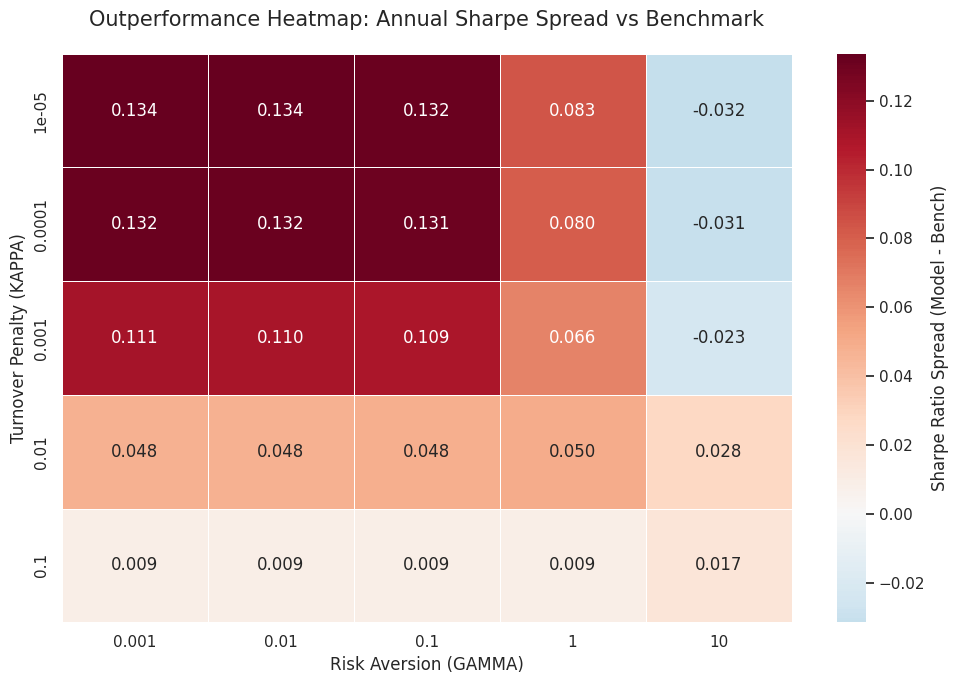

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the difference between Portfolio Sharpe and Benchmark Sharpe
results_df['sharpe_spread'] = results_df['sharpe_annual'] - results_df['bench_sharpe_annual']

# Prepare the data for heatmap
relative_data = results_df.pivot(index='kappa', columns='gamma', values='sharpe_spread')

plt.figure(figsize=(10, 7))
sns.set_theme(style='white')

# Use a diverging colormap (RdBu_r) to center 0 (no difference)
ax = sns.heatmap(
    relative_data,
    annot=True,
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Sharpe Ratio Spread (Model - Bench)'}
)

# Format labels
ax.set_xticklabels([f'{float(x):.3g}' for x in relative_data.columns])
ax.set_yticklabels([f'{float(x):.3g}' for x in relative_data.index])

plt.title('Outperformance Heatmap: Annual Sharpe Spread vs Benchmark', fontsize=15, pad=20)
plt.xlabel('Risk Aversion (GAMMA)', fontsize=12)
plt.ylabel('Turnover Penalty (KAPPA)', fontsize=12)

plt.tight_layout()
plt.show()

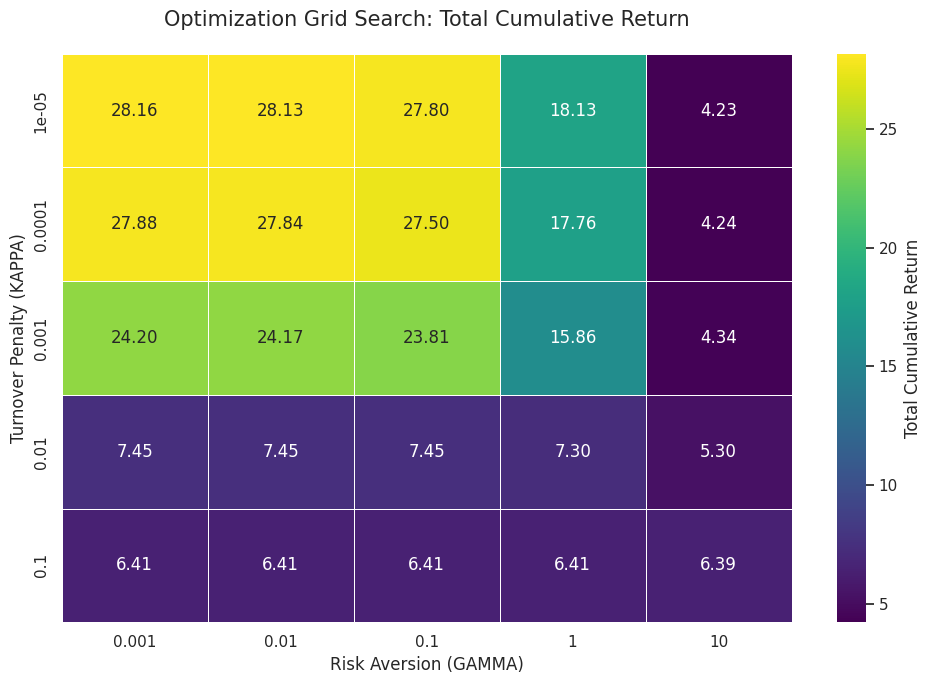

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare the data for cumulative return heatmap
heatmap_return_data = results_df.pivot(index='kappa', columns='gamma', values='cum_return')

plt.figure(figsize=(10, 7))
sns.set_theme(style='white')

# Use a high-contrast colormap to highlight performance peaks
ax = sns.heatmap(
    heatmap_return_data,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Total Cumulative Return'}
)

# Format the axis labels
ax.set_xticklabels([f'{float(x):.3g}' for x in heatmap_return_data.columns])
ax.set_yticklabels([f'{float(x):.3g}' for x in heatmap_return_data.index])

plt.title('Optimization Grid Search: Total Cumulative Return', fontsize=15, pad=20)
plt.xlabel('Risk Aversion (GAMMA)', fontsize=12)
plt.ylabel('Turnover Penalty (KAPPA)', fontsize=12)

plt.tight_layout()
plt.show()

Here, comparing the optimized portfolio to the S&P 500 serves a different purpose than comparing it to the equal weight benchmark on the same universe. The equal weight portfolio tells us whether the optimization procedure adds value relative to a naive allocation rule over the same set of stocks. By contrast, the S&P 500 provides a standard external benchmark that investors actually recognize and use in practice. If the optimized portfolio performs well relative to the S&P 500, that suggests the strategy is not only improving on a naive allocation within its own universe, but is also competitive with a broad market portfolio. This makes the results more practically meaningful from an investor’s perspective, since the relevant question is often not merely whether the optimization beats an internal benchmark, but whether it offers a credible alternative to simply investing in the market.

/tmp/ipykernel_10202/152354479.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  spy_monthly = spy["Close"].resample("M").last()


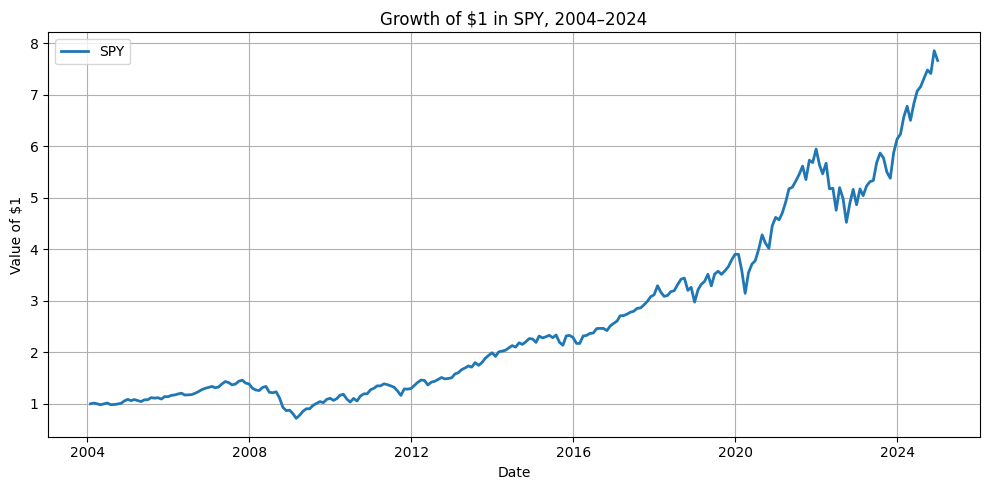

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# Download SPY data from 2004 to 2024
spy = yf.download("SPY", start="2004-01-01", end="2025-01-01", auto_adjust=True, progress=False)

# Monthly prices
spy_monthly = spy["Close"].resample("M").last()

# Growth of $1
growth = spy_monthly / spy_monthly.iloc[0]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(growth.index, growth.values, linewidth=2, label="SPY")
plt.title("Growth of $1 in SPY, 2004–2024")
plt.xlabel("Date")
plt.ylabel("Value of $1")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_10202/569443000.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = prices.resample("M").last().dropna()


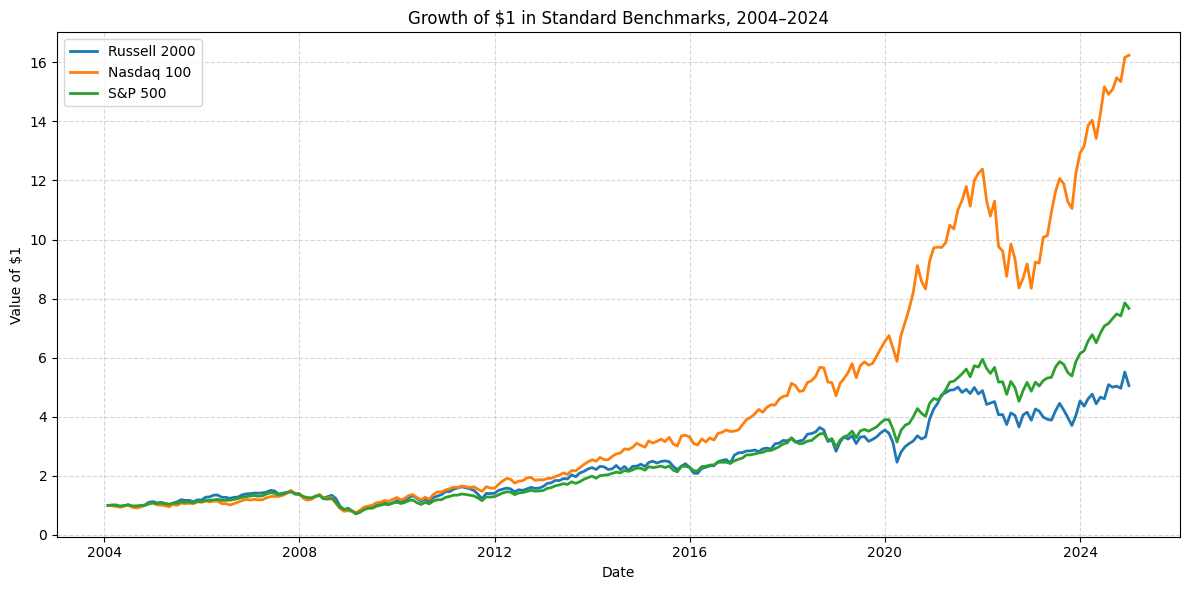

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Benchmark ETFs
benchmark_tickers = {
    "SPY": "S&P 500",
    "QQQ": "Nasdaq 100",
    "IWM": "Russell 2000"
}

# Download adjusted prices
prices = yf.download(
    list(benchmark_tickers.keys()),
    start="2004-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

# Monthly prices
monthly_prices = prices.resample("M").last().dropna()

# Growth of $1
growth_df = monthly_prices / monthly_prices.iloc[0]
growth_df = growth_df.rename(columns=benchmark_tickers)

# Plot
plt.figure(figsize=(12, 6))
for col in growth_df.columns:
    plt.plot(growth_df.index, growth_df[col], label=col, linewidth=2)

plt.title("Growth of $1 in Standard Benchmarks, 2004–2024")
plt.xlabel("Date")
plt.ylabel("Value of $1")
plt.legend()
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()